<a href="https://colab.research.google.com/github/abhioverdue/Normalization-Across-Datasets-A-Study/blob/main/MNIST_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Normalization Study - MNIST
# BatchNorm vs LayerNorm vs GroupNorm vs None

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# Seed Function

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
# Dataset

def get_dataloaders(batch_size):
    transform = transforms.ToTensor()
    train_dataset = torchvision.datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = torchvision.datasets.MNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=batch_size
    )

    return train_loader, test_loader

In [ ]:
# Model
class CNN(nn.Module):

    def __init__(self, norm="batch"):
        super().__init__()

        self.conv1 = nn.Conv2d(1,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)

        if norm == "batch":
            self.norm1 = nn.BatchNorm2d(32)
            self.norm2 = nn.BatchNorm2d(64)

        elif norm == "layer":
            self.norm1 = nn.GroupNorm(1,32)
            self.norm2 = nn.GroupNorm(1,64)

        elif norm == "group":
            self.norm1 = nn.GroupNorm(8,32)
            self.norm2 = nn.GroupNorm(8,64)

        else:
            self.norm1 = nn.Identity()
            self.norm2 = nn.Identity()

        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(64*14*14,10)

    def forward(self,x):

        x = torch.relu(self.norm1(self.conv1(x)))
        x = torch.relu(self.norm2(self.conv2(x)))
        x = self.pool(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)
        return x


In [ ]:
# Evaluate

def evaluate(model,loader):

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images,labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _,pred = torch.max(outputs,1)
            total += labels.size(0)
            correct += (pred==labels).sum().item()

    return correct/total

In [ ]:
# Train
def train_model(model,train_loader,test_loader,epochs=5):

    model.to(device)
    optimizer = optim.Adam(model.parameters(),lr=0.001)
    criterion = nn.CrossEntropyLoss()
    train_losses=[]
    grad_norms=[]
    for epoch in range(epochs):
        model.train()
        epoch_loss=0
        grad_epoch=0
        for images,labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)
            loss.backward()
            grad_norm=0
            for p in model.parameters():
                if p.grad is not None:
                    grad_norm += p.grad.data.norm(2).item()
            grad_epoch += grad_norm
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss/len(train_loader))
        grad_norms.append(grad_epoch/len(train_loader))
    acc = evaluate(model,test_loader)
    return train_losses,grad_norms,acc

In [ ]:
# Experiment

batch_sizes=[64,32,8,4,2]
norms=["batch","layer","group","none"]
seeds=[0,1,2]
results=[]
for norm in norms:
    for bs in batch_sizes:
        for seed in seeds:
            print("Norm:",norm,"Batch:",bs,"Seed:",seed)
            set_seed(seed)
            train_loader,test_loader=get_dataloaders(bs)
            model=CNN(norm)
            loss,grad,acc=train_model(model,train_loader,test_loader)
            results.append({
                "norm":norm,
                "batch_size":bs,
                "seed":seed,
                "accuracy":acc,
                "grad_norm":np.mean(grad)
            })

Norm: batch Batch: 64 Seed: 0


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.69MB/s]


Norm: batch Batch: 64 Seed: 1
Norm: batch Batch: 64 Seed: 2
Norm: batch Batch: 32 Seed: 0
Norm: batch Batch: 32 Seed: 1
Norm: batch Batch: 32 Seed: 2
Norm: batch Batch: 8 Seed: 0
Norm: batch Batch: 8 Seed: 1
Norm: batch Batch: 8 Seed: 2
Norm: batch Batch: 4 Seed: 0
Norm: batch Batch: 4 Seed: 1
Norm: batch Batch: 4 Seed: 2
Norm: batch Batch: 2 Seed: 0
Norm: batch Batch: 2 Seed: 1
Norm: batch Batch: 2 Seed: 2
Norm: layer Batch: 64 Seed: 0
Norm: layer Batch: 64 Seed: 1
Norm: layer Batch: 64 Seed: 2
Norm: layer Batch: 32 Seed: 0
Norm: layer Batch: 32 Seed: 1
Norm: layer Batch: 32 Seed: 2
Norm: layer Batch: 8 Seed: 0
Norm: layer Batch: 8 Seed: 1
Norm: layer Batch: 8 Seed: 2
Norm: layer Batch: 4 Seed: 0
Norm: layer Batch: 4 Seed: 1
Norm: layer Batch: 4 Seed: 2
Norm: layer Batch: 2 Seed: 0
Norm: layer Batch: 2 Seed: 1
Norm: layer Batch: 2 Seed: 2
Norm: group Batch: 64 Seed: 0
Norm: group Batch: 64 Seed: 1
Norm: group Batch: 64 Seed: 2
Norm: group Batch: 32 Seed: 0
Norm: group Batch: 32 Seed: 

In [ ]:
# Save

df=pd.DataFrame(results)
print(df)
df.to_csv("mnist_full_results.csv",index=False)

     norm  batch_size  seed  accuracy  grad_norm
0   batch          64     0    0.9865   2.228092
1   batch          64     1    0.9872   2.298646
2   batch          64     2    0.9865   2.235272
3   batch          32     0    0.9873   2.082411
4   batch          32     1    0.9872   2.132597
5   batch          32     2    0.9871   2.080856
6   batch           8     0    0.9882   1.643248
7   batch           8     1    0.9890   1.582902
8   batch           8     2    0.9854   1.609075
9   batch           4     0    0.9887   1.435194
10  batch           4     1    0.9878   1.377814
11  batch           4     2    0.9843   1.413413
12  batch           2     0    0.9877   1.305586
13  batch           2     1    0.9869   1.289560
14  batch           2     2    0.9871   1.302174
15  layer          64     0    0.9870   2.315108
16  layer          64     1    0.9858   2.152683
17  layer          64     2    0.9866   2.468089
18  layer          32     0    0.9872   2.005969
19  layer          3

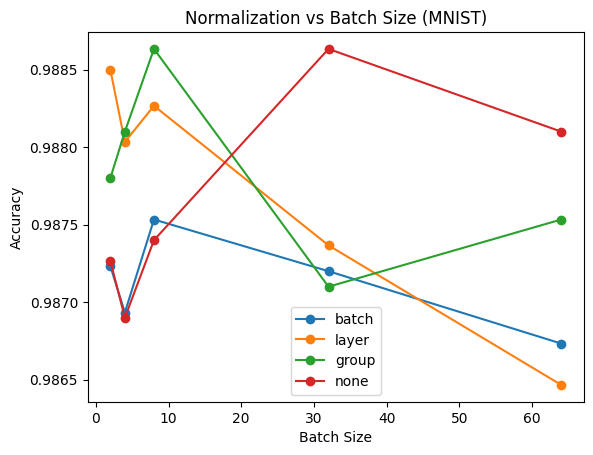

In [ ]:
# Plot

plt.figure()
for norm in norms:
    subset=df[df.norm==norm]
    mean_acc=subset.groupby("batch_size").accuracy.mean()
    plt.plot(mean_acc.index,mean_acc.values,marker="o",label=norm)

plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.title("Normalization vs Batch Size (MNIST)")
plt.legend()
plt.show()